# **1. PREPARACIÓN Y ANÁLISIS INICIAL DE LA BBDD**

**CARGA DE LIBRERÍAS Y EXCEL**


In [ ]:
from google.colab import drive
import pandas as pd
import os

drive.mount('/content/drive')

print(os.listdir('/content/drive/MyDrive'))

ruta = '/content/drive/MyDrive/MA.xlsx'
df = pd.read_excel(ruta)

import pandas as pd
import numpy as np
import pandas as pd #Operaciones matemáticas y trabajar con arreglos multidimensionales (arrays).
import numpy as np #Manipular y analizar datos estructurados.
import matplotlib.pyplot as plt #Crear gráficos de líneas, barras, histogramas, etc
import seaborn as sns #Gráficos más estilizados y fáciles de interpretar.
import plotly.express as px #Visualizaciones avanzadas e interactivas q


print(df.shape)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Timber (feat. Ke$ha).mov', 'SIMULACRO 1. MATEMÁTICAS CUNEF.gdoc', 'Bloque 6.gdoc', 'Chrome Syncable FileSystem', 'bb.JPG', 'a.JPG', 'cc.JPG', 'ccccc.JPG', 'd.JPG', 'dd.JPG', 'ddd.JPG', 'Downloads.JPG', 's.JPG', 't.JPG', 'x.JPG', 'y.JPG', 'z.JPG', 'Google Earth', 'Documento sin título.gdoc', 'workshops final.pdf', 'workshops final.gdoc', 'Colab Notebooks', 'Untitled0.ipynb', 'Fwd: Fwd: Fwd: flat Paris bedroom -2 (1).eml', 'Fwd: Fwd: appartment : view from the entrance hall of a section of the sitting rooms with on the rignt door to the kitchen, corridor and acces to main bedroom (1).eml', 'Fwd: Fwd: Fwd: Fwd: flat Paris (1).eml', 'Fwd: Fwd: Fwd: Fwd: Fwd: Flat Paris bedroom-2 (1).eml', 'Fwd: mas fotos de la cocina y baño. (1).eml', 'Fwd: Fwd: Fwd: Fwd: flat Paris.eml', 'Fwd: Fwd: Fwd: flat Paris bedroom -2.eml', 'Fwd: Fwd: appartment : view from the entra

,Deal ID,Transaction Status,Target,Target FactSet Industry,Target Country,Acquirer,Private Equity Acquisition,Transaction Value (MM),Enterprise Value (MM),Base Equity Value (MM),Revenue - Target (LTM) (MM),EBITDA - Target (LTM) (MM),EBIT - Target (LTM) (MM),Net Income - Target (LTM) (MM),Total Assets - Target (MM),Long Term Debt - Target (MM),Cash - Target (MM),EV/EBITDA,P/E,Synopsis
0,46229MM,Cancelled,Critchley Group Plc,Electronic Production Equipment,United Kingdom,Brady Corp.,0,152.767878,152.767878,153.73000,76.326250,15.82460,9.91518,8.668138,95.921636,12.607674,31.867873,9.653822,17.735066,Brady had its offer to acquire all of the outs...
1,47307MM,Cancelled,Shared Medical Systems Corp.,Information Technology Services,United States,Eclipsys Corp.,0,1926.790000,1926.790000,1802.26000,1215.445000,183.31700,133.00500,75.972000,915.744000,178.217000,104.700000,10.510700,23.722687,Eclipsys cancelled an agreement to acquire Sha...
2,49942MM,Cancelled,Laser Power Corp.,Electronic Components,United States,Union Miniere SA,0,39.616000,43.851555,38.12000,32.455177,4.55208,3.74730,3.332953,20.805000,1.445000,2.051000,9.633301,12.708119,"Union Miniere USA, a subsidiary of Union Minie..."
3,50070MM,Cancelled,"Computer Research, Inc.",Packaged Software,United States,FIS Capital Markets US LLC (Pennsylvania),0,4.602844,4.602844,8.07000,8.273902,1.31104,1.05214,0.737907,5.470804,0.104342,3.647526,3.510834,10.936337,SunGard Data Systems terminated its letter of ...
4,53288MM,Cancelled,Allgon AB /Old/,Telecommunications Equipment,Sweden,"REMEC, Inc.",0,491.152590,491.152590,469.97736,258.170120,24.11732,13.09226,9.755726,161.617693,10.722228,6.613602,20.365140,48.174514,REMEC cancelled its definitive agreement to ac...


**CHECK DE NULOS Y DUPLICADOS**

In [ ]:
# NULOS
missing = df.isna().sum().sort_values(ascending=False) # calcula el número de valores nulos por columna y los ordena de mayor a menor
missing.head(20)

,0
Deal ID,0
Transaction Status,0
Target,0
Target FactSet Industry,0
Target Country,0
Acquirer,0
Private Equity Acquisition,0
Transaction Value (MM),0
Enterprise Value (MM),0
Base Equity Value (MM),0


In [ ]:
# DUPLICADOS
# Duplicados por Deal ID (si existe)
if "Deal ID" in df.columns:
    print("Duplicados Deal ID:", df["Deal ID"].duplicated().sum()) # cuenta cuántas operaciones están repetidas en función del ID

Duplicados Deal ID: 0


**DEPURACIÓN DE VARIABLES EXPLICATIVAS**

In [ ]:
#Eliminamos variables explicativas
cols_drop = ["Deal ID", "Acquirer", "Synopsis"] # lista de columnas que no aportan valor predictivo
dataf = df.drop(columns=cols_drop) # elimina dichas columnas del dataset
dataf

,Transaction Status,Target,Target FactSet Industry,Target Country,Private Equity Acquisition,Transaction Value (MM),Enterprise Value (MM),Base Equity Value (MM),Revenue - Target (LTM) (MM),EBITDA - Target (LTM) (MM),EBIT - Target (LTM) (MM),Net Income - Target (LTM) (MM),Total Assets - Target (MM),Long Term Debt - Target (MM),Cash - Target (MM),EV/EBITDA,P/E
0,Cancelled,Critchley Group Plc,Electronic Production Equipment,United Kingdom,0,152.767878,152.767878,153.730000,76.326250,15.82460,9.91518,8.668138,95.921636,12.607674,31.867873,9.653822,17.735066
1,Cancelled,Shared Medical Systems Corp.,Information Technology Services,United States,0,1926.790000,1926.790000,1802.260000,1215.445000,183.31700,133.00500,75.972000,915.744000,178.217000,104.700000,10.510700,23.722687
2,Cancelled,Laser Power Corp.,Electronic Components,United States,0,39.616000,43.851555,38.120000,32.455177,4.55208,3.74730,3.332953,20.805000,1.445000,2.051000,9.633301,12.708119
3,Cancelled,"Computer Research, Inc.",Packaged Software,United States,0,4.602844,4.602844,8.070000,8.273902,1.31104,1.05214,0.737907,5.470804,0.104342,3.647526,3.510834,10.936337
4,Cancelled,Allgon AB /Old/,Telecommunications Equipment,Sweden,0,491.152590,491.152590,469.977360,258.170120,24.11732,13.09226,9.755726,161.617693,10.722228,6.613602,20.365140,48.174514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032,Complete,Global Blue Group Holding AG,Data Processing Services,Switzerland,0,2226.010517,2226.010517,1801.312618,526.684989,140.47033,83.47127,70.028112,1201.329112,549.913666,126.099048,15.846838,25.722707
1033,Complete,Anacle Systems Ltd.,Packaged Software,Singapore,0,52.932656,52.932656,57.567509,22.449578,1.89615,0.78645,0.829525,17.594197,0.618616,6.161463,27.915859,69.398160
1034,Complete,Tecnos Japan Inc.,Information Technology Services,Japan,1,12.862155,126.084509,12.862155,91.523291,12.58918,11.61668,7.836059,66.009415,1.861161,25.532692,10.015308,19.038065
1035,Complete,"Wacul, Inc.",Information Technology Services,Japan,0,21.910902,21.910902,27.007540,12.121227,1.52242,0.70212,0.610175,14.768200,2.345984,8.305982,14.392153,44.261957


**CONVERSIÓN DE LA VARIABLE TARGET A NUMÉRICA**

In [ ]:
dataf['Transaction Status'] = dataf['Transaction Status'].replace({'Complete': 1, 'Cancelled': 0})
dataf # convierte la variable categórica en numérica: 1 = operación completada, 0 = operación cancelada

/tmp/ipykernel_1813/1236503855.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataf['Transaction Status'] = dataf['Transaction Status'].replace({'Complete': 1, 'Cancelled': 0})


,Transaction Status,Target,Target FactSet Industry,Target Country,Private Equity Acquisition,Transaction Value (MM),Enterprise Value (MM),Base Equity Value (MM),Revenue - Target (LTM) (MM),EBITDA - Target (LTM) (MM),EBIT - Target (LTM) (MM),Net Income - Target (LTM) (MM),Total Assets - Target (MM),Long Term Debt - Target (MM),Cash - Target (MM),EV/EBITDA,P/E
0,0,Critchley Group Plc,Electronic Production Equipment,United Kingdom,0,152.767878,152.767878,153.730000,76.326250,15.82460,9.91518,8.668138,95.921636,12.607674,31.867873,9.653822,17.735066
1,0,Shared Medical Systems Corp.,Information Technology Services,United States,0,1926.790000,1926.790000,1802.260000,1215.445000,183.31700,133.00500,75.972000,915.744000,178.217000,104.700000,10.510700,23.722687
2,0,Laser Power Corp.,Electronic Components,United States,0,39.616000,43.851555,38.120000,32.455177,4.55208,3.74730,3.332953,20.805000,1.445000,2.051000,9.633301,12.708119
3,0,"Computer Research, Inc.",Packaged Software,United States,0,4.602844,4.602844,8.070000,8.273902,1.31104,1.05214,0.737907,5.470804,0.104342,3.647526,3.510834,10.936337
4,0,Allgon AB /Old/,Telecommunications Equipment,Sweden,0,491.152590,491.152590,469.977360,258.170120,24.11732,13.09226,9.755726,161.617693,10.722228,6.613602,20.365140,48.174514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032,1,Global Blue Group Holding AG,Data Processing Services,Switzerland,0,2226.010517,2226.010517,1801.312618,526.684989,140.47033,83.47127,70.028112,1201.329112,549.913666,126.099048,15.846838,25.722707
1033,1,Anacle Systems Ltd.,Packaged Software,Singapore,0,52.932656,52.932656,57.567509,22.449578,1.89615,0.78645,0.829525,17.594197,0.618616,6.161463,27.915859,69.398160
1034,1,Tecnos Japan Inc.,Information Technology Services,Japan,1,12.862155,126.084509,12.862155,91.523291,12.58918,11.61668,7.836059,66.009415,1.861161,25.532692,10.015308,19.038065
1035,1,"Wacul, Inc.",Information Technology Services,Japan,0,21.910902,21.910902,27.007540,12.121227,1.52242,0.70212,0.610175,14.768200,2.345984,8.305982,14.392153,44.261957


**ANÁLISIS VARIABLES NUMÉRCIAS Y CATEGÓRICAS**

In [ ]:
#ANÁLISIS VARIABLES CATEEGÓRICAS VS NUMÉRICAS
num_cols = dataf.select_dtypes(include=[np.number]).columns.tolist() # Selección de variables numéricas e identifica columna con valores numéricos
cat_cols = dataf.select_dtypes(include=["object"]).columns.tolist() # Selección de variables categóricas e identifica columna con valores categóricas

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['Transaction Status', 'Private Equity Acquisition', 'Transaction Value (MM)', 'Enterprise Value (MM)', 'Base Equity Value (MM)', 'Revenue - Target (LTM) (MM)', 'EBITDA - Target (LTM) (MM)', 'EBIT - Target (LTM) (MM)', 'Net Income - Target (LTM) (MM)', 'Total Assets - Target (MM)', 'Long Term Debt - Target (MM)', 'Cash - Target (MM)', 'EV/EBITDA', 'P/E']
Categóricas: ['Target', 'Target FactSet Industry', 'Target Country']




---



---



---



# **2. ANÁLISIS EXPLORATORIO-DESCRIPTIVO DEL DATASET (EDA)**

**2.1. ESTADÍSTICAS DESCRIPTIVAS**

In [ ]:
descriptive_stats = dataf.describe()
print("Estadísticas descriptivas:")
print(descriptive_stats)

Estadísticas descriptivas:
       Transaction Status  Private Equity Acquisition  Transaction Value (MM)  \
count         1037.000000                 1037.000000             1037.000000   
mean             0.835101                    0.236258             2033.782357   
std              0.371268                    0.424988             6694.285145   
min              0.000000                    0.000000                0.910578   
25%              1.000000                    0.000000               55.987225   
50%              1.000000                    0.000000              237.501000   
75%              1.000000                    0.000000             1257.577870   
max              1.000000                    1.000000           105974.790436   

       Enterprise Value (MM)  Base Equity Value (MM)  \
count            1037.000000             1037.000000   
mean             2138.612520             1929.723826   
std              6832.661909             6730.320281   
min                




---





**2.2. ANÁLISIS DE CORRELACIONES**

*   Matriz de correlación
*   Depuración de variables
*   Selección de variables





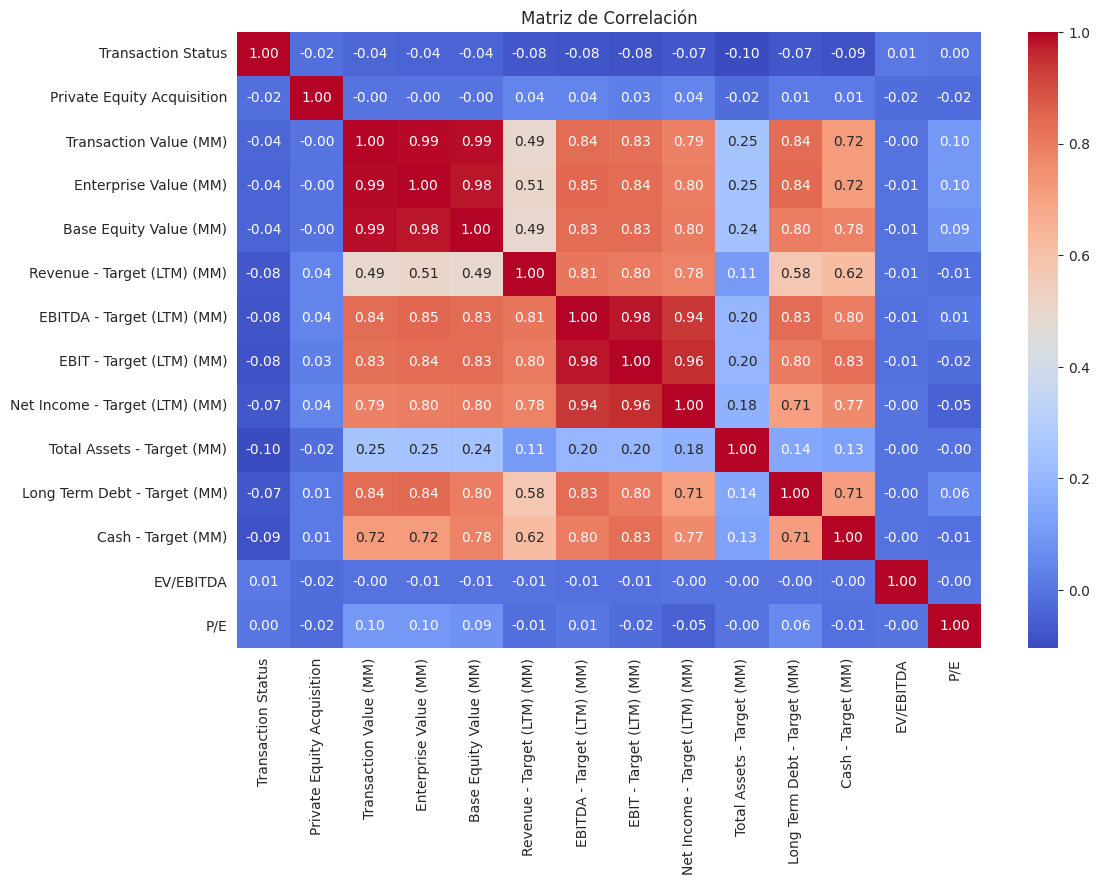

In [ ]:

# Matriz de correlación
correlation_matrix = dataf.corr(numeric_only=True)  # Usar solo columnas numéricas

# Visualizar la matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f",
cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlación")
plt.show()

In [ ]:
#Búsqueda de correlaciones más altas
corr_pairs = correlation_matrix.unstack() # convierte la matriz en una lista de pares de variables con su correlación

corr_pairs = corr_pairs.sort_values(ascending=False) #orden de mayor a menor

corr_pairs = corr_pairs[corr_pairs != 1]  # eliminar autocorrelaciones

corr_pairs.head(20)


Enterprise Value (MM)           Transaction Value (MM)            0.994689
Transaction Value (MM)          Enterprise Value (MM)             0.994689
                                Base Equity Value (MM)            0.989348
Base Equity Value (MM)          Transaction Value (MM)            0.989348
EBITDA - Target (LTM) (MM)      EBIT - Target (LTM) (MM)          0.982413
EBIT - Target (LTM) (MM)        EBITDA - Target (LTM) (MM)        0.982413
Enterprise Value (MM)           Base Equity Value (MM)            0.982308
Base Equity Value (MM)          Enterprise Value (MM)             0.982308
EBIT - Target (LTM) (MM)        Net Income - Target (LTM) (MM)    0.956157
Net Income - Target (LTM) (MM)  EBIT - Target (LTM) (MM)          0.956157
                                EBITDA - Target (LTM) (MM)        0.935915
EBITDA - Target (LTM) (MM)      Net Income - Target (LTM) (MM)    0.935915
                                Enterprise Value (MM)             0.846471
Enterprise Value (MM)           EBITDA - Target (LTM) (MM)        0.846471
                                Long Term Debt - Target (MM)      0.844774
Long Term Debt - Target (MM)    Enterprise Value (MM)             0.844774
                                Transaction Value (MM)            0.836046
Transaction Value (MM)          Long Term Debt - Target (MM)      0.836046
Enterprise Value (MM)           EBIT - Target (LTM) (MM)          0.836019
EBIT - Target (LTM) (MM)        Enterprise Value (MM)             0.836019
dtype: float64



*   Depuración de variables


In [ ]:
# Bloques económicos
group_A_value = ["Transaction Value (MM)", "Enterprise Value (MM)", "Base Equity Value (MM)"]

group_B_profit = ["Revenue - Target (LTM) (MM)", "EBITDA - Target (LTM) (MM)",
                  "EBIT - Target (LTM) (MM)", "Net Income - Target (LTM) (MM)"]

group_C_balance = ["Total Assets - Target (MM)", "Long Term Debt - Target (MM)", "Cash - Target (MM)"]

group_D_multiples = ["EV/EBITDA", "P/E"]

group_E_strategic = ["Private Equity Acquisition", "Target FactSet Industry", "Target Country"]

In [ ]:
#Calculo de correlcaciones de cada bloque para justificar que estos bloques miden lo mismo y que hay correlaciones muy altas entre estas variables
corr_A = dataf[group_A_value].corr()
corr_A.round(3)

,Transaction Value (MM),Enterprise Value (MM),Base Equity Value (MM)
Transaction Value (MM),1.000,0.995,0.989
Enterprise Value (MM),0.995,1.000,0.982
Base Equity Value (MM),0.989,0.982,1.000


In [ ]:
corr_B = dataf[group_B_profit].corr()
corr_B.round(3)

,Revenue - Target (LTM) (MM),EBITDA - Target (LTM) (MM),EBIT - Target (LTM) (MM),Net Income - Target (LTM) (MM)
Revenue - Target (LTM) (MM),1.000,0.811,0.799,0.781
EBITDA - Target (LTM) (MM),0.811,1.000,0.982,0.936
EBIT - Target (LTM) (MM),0.799,0.982,1.000,0.956
Net Income - Target (LTM) (MM),0.781,0.936,0.956,1.000


In [ ]:
corr_C = dataf[group_C_balance].corr()
corr_C.round(3)
#se observa que las correlaciones no son muy altas lo que justifica manetener ambas metricas

,Total Assets - Target (MM),Long Term Debt - Target (MM),Cash - Target (MM)
Total Assets - Target (MM),1.000,0.143,0.129
Long Term Debt - Target (MM),0.143,1.000,0.713
Cash - Target (MM),0.129,0.713,1.000


In [ ]:
corr_D = dataf[group_D_multiples].corr()
corr_D.round(3)
#se observa que las correlaciones no son muy altas lo que justifica manetener ambas metricas

,EV/EBITDA,P/E
EV/EBITDA,1.000,-0.002
P/E,-0.002,1.000


In [ ]:
#Tabla de decisión, selección de variables que se mantienen por cada bloque
selection_table = pd.DataFrame({
    "Bloque": ["A - Valor", "A - Valor", "A - Valor",
               "B - Rentabilidad", "B - Rentabilidad", "B - Rentabilidad", "B - Rentabilidad"], # indica a qué grupo económico pertenece cada variable (valor o rentabilidad)
    "Variable": group_A_value + group_B_profit, # combina las variables de los bloques A (valor) y B (rentabilidad) en una sola lista
})

# Añadir columna recomendación manual
def recommendation(var):
    if var == "Enterprise Value (MM)": return "Mantener (representa valor del deal)"
    if var in ["Transaction Value (MM)", "Base Equity Value (MM)"]: return "Eliminar (redundante con EV)"
    if var == "EBITDA - Target (LTM) (MM)": return "Mantener (métrica estándar M&A)"
    if var in ["EBIT - Target (LTM) (MM)", "Net Income - Target (LTM) (MM)", "Revenue - Target (LTM) (MM)"]:
        return "Eliminar (redundante con EBITDA / tamaño)"
    return ""

selection_table["Decisión"] = selection_table["Variable"].apply(recommendation) # Aplicar la función a cada variable y crea una nueva columna con la decisión (mantener/eliminar)
selection_table

,Bloque,Variable,Decisión
0,A - Valor,Transaction Value (MM),Eliminar (redundante con EV)
1,A - Valor,Enterprise Value (MM),Mantener (representa valor del deal)
2,A - Valor,Base Equity Value (MM),Eliminar (redundante con EV)
3,B - Rentabilidad,Revenue - Target (LTM) (MM),Eliminar (redundante con EBITDA / tamaño)
4,B - Rentabilidad,EBITDA - Target (LTM) (MM),Mantener (métrica estándar M&A)
5,B - Rentabilidad,EBIT - Target (LTM) (MM),Eliminar (redundante con EBITDA / tamaño)
6,B - Rentabilidad,Net Income - Target (LTM) (MM),Eliminar (redundante con EBITDA / tamaño)




*   Selección final variables



In [ ]:
#Selección final de variables + creación del nuevo dataframe -> pasamos a tener 11 variables
selected_features = [
    "Enterprise Value (MM)",                     # Grupo A
    "EBITDA - Target (LTM) (MM)",               # Grupo B
    "Total Assets - Target (MM)",               # Grupo C
    "Long Term Debt - Target (MM)",             # Grupo C
    "Cash - Target (MM)",                       # Grupo C
    "EV/EBITDA", "P/E",                         # Grupo D
    "Private Equity Acquisition",               # Grupo E
    "Target FactSet Industry", "Target Country" # Grupo E
]

# Solo las que existan
selected_features = [c for c in selected_features if c in dataf.columns]

dff = dataf[selected_features + ["Transaction Status"]].copy()  # y si ya la tienes
print(dff.shape)
dff.head()

(1037, 11)


,Enterprise Value (MM),EBITDA - Target (LTM) (MM),Total Assets - Target (MM),Long Term Debt - Target (MM),Cash - Target (MM),EV/EBITDA,P/E,Private Equity Acquisition,Target FactSet Industry,Target Country,Transaction Status
0,152.767878,15.82460,95.921636,12.607674,31.867873,9.653822,17.735066,0,Electronic Production Equipment,United Kingdom,0
1,1926.790000,183.31700,915.744000,178.217000,104.700000,10.510700,23.722687,0,Information Technology Services,United States,0
2,43.851555,4.55208,20.805000,1.445000,2.051000,9.633301,12.708119,0,Electronic Components,United States,0
3,4.602844,1.31104,5.470804,0.104342,3.647526,3.510834,10.936337,0,Packaged Software,United States,0
4,491.152590,24.11732,161.617693,10.722228,6.613602,20.365140,48.174514,0,Telecommunications Equipment,Sweden,0


**2.3. VISUALIZACIÓN DE LAS RELACIONES ENTRE VARIABLES**


*   #1 Scatter Plot EV vs EBITDA
*   #2 Histograma Enterprise Value
*   #3 Distribución operaciones Private Equity
*   #4 Top países
*   #5 Top industrias
*   #6 Box plot EV vs Status







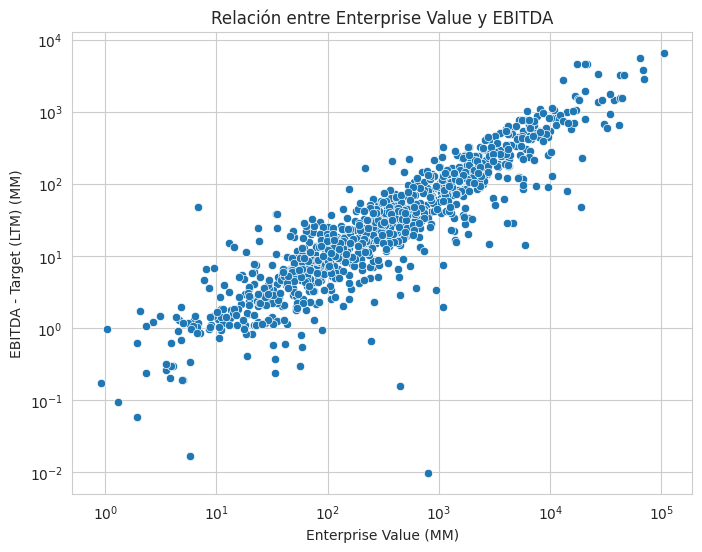

In [ ]:
# 1. Scatter EV vs EBITDA
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Enterprise Value (MM)",
    y="EBITDA - Target (LTM) (MM)",
    data=dff
)
plt.xscale("log")
plt.yscale("log")
plt.title("Relación entre Enterprise Value y EBITDA")
plt.show()

/tmp/ipykernel_1813/1254128573.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=pe, x="PE", y="success_rate", palette="Set2")


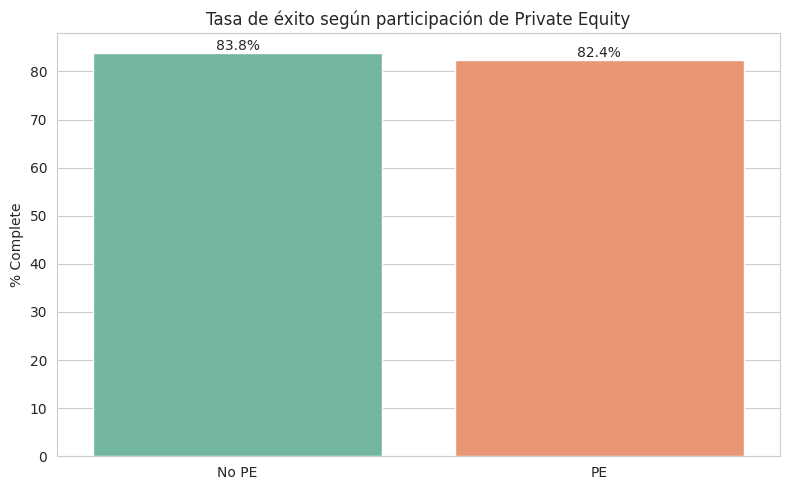

In [ ]:
# 2. Gráfico de barras Private Equity
pe = (dff.groupby("Private Equity Acquisition")["Transaction Status"]
      .agg(mean="mean", n="count")
      .reset_index())
# Agrupa las operaciones según si hay Private Equity o no
# - mean → calcula la media del Transaction Status (proporción de operaciones completadas)
# - n → número de observaciones en cada grupo

pe["success_rate"] = pe["mean"] * 100 #cálculo de la tasa de éxito
pe["PE"] = pe["Private Equity Acquisition"].map({0:"No PE", 1:"PE"}).fillna(pe["Private Equity Acquisition"].astype(str)) # Sustituye valores numéricos por etiquetas legibles:
# 0 → No PE, 1 → PE

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=pe, x="PE", y="success_rate", palette="Set2")
plt.title("Tasa de éxito según participación de Private Equity")
plt.xlabel("")
plt.ylabel("% Complete")

for p in ax.patches: #añadir valores sobre barras
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")

plt.tight_layout()
plt.show()

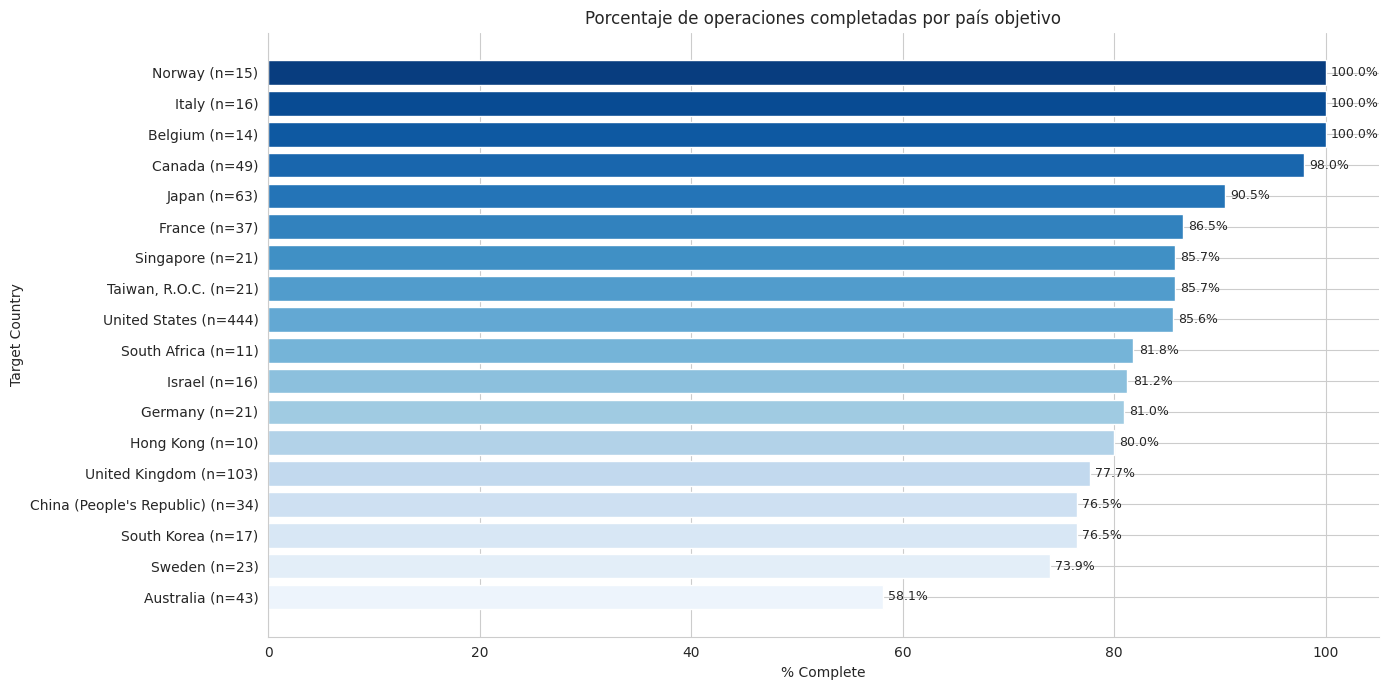

In [ ]:
#3. Gráfico de barras: Porcentaje de operaciones completadas por país
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

min_obs_country = 10 # Se establece un mínimo de observaciones por país para evitar resultados poco representativos

# CÁLCULO DE ESTADÍSTICAS POR PAÍS
country_stats = (
    dff.groupby("Target Country")
    .agg(
        total_ops=("Transaction Status", "count"),  # número total de operaciones por país
        pct_complete=("Transaction Status", "mean") # proporción de operaciones completadas
    )
    .reset_index()
)
# FILTRAR PAÍSES CON POCOS DATOS
country_stats = country_stats[country_stats["total_ops"] >= min_obs_country].copy() # Se eliminan países con menos de 10 operaciones para evitar ruido estadístico
country_stats["pct_complete"] = country_stats["pct_complete"] * 100 # Conversión a porcentaje
country_stats = country_stats.sort_values("pct_complete", ascending=True) #orden de resultados

# Etiquetas con número de obervaciones
country_stats["label"] = (
    country_stats["Target Country"] + " (n=" + country_stats["total_ops"].astype(str) + ")"
)

# Paleta degradada
colors = sns.color_palette("Blues", n_colors=len(country_stats))

plt.figure(figsize=(14, 7)) # Gráfico de barras horizontal para comparar países fácilmente
bars = plt.barh(
    country_stats["label"],
    country_stats["pct_complete"],
    color=colors
)

plt.xlabel("% Complete")
plt.ylabel("Target Country")
plt.title("Porcentaje de operaciones completadas por país objetivo")

for i, v in enumerate(country_stats["pct_complete"]):
    plt.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9) # Se muestran los porcentajes exactos sobre cada barra

plt.xlim(0, min(105, country_stats["pct_complete"].max() + 8)) # Ajusta el eje para que no quede el gráfico comprimido
sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()

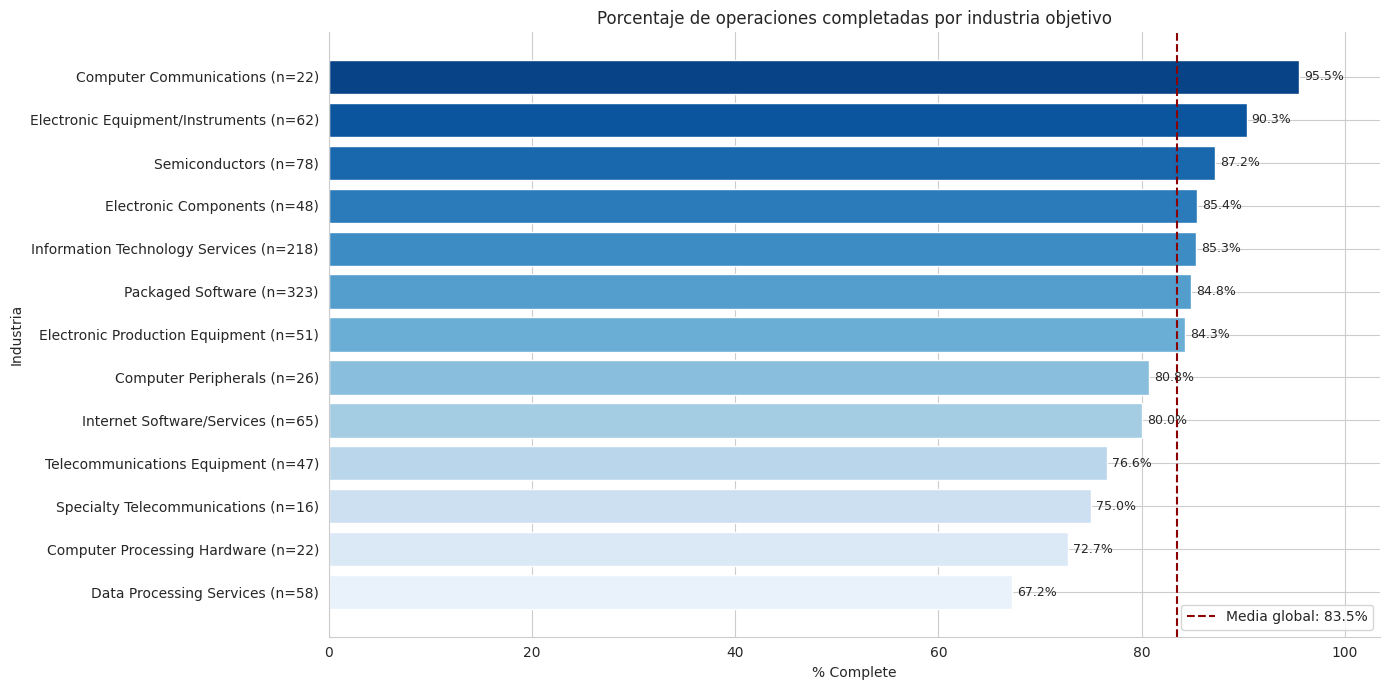

In [ ]:
#4. Gráfico barras: Porcentaje de operaciones completadas por sector

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# mínimo de observaciones por industria para evitar conclusiones débiles
min_obs_industry = 10

industry_stats = (
    dataf.groupby("Target FactSet Industry")
    .agg(
        total_ops=("Transaction Status", "count"),
        success_rate=("Transaction Status", "mean")
    )
    .reset_index()
)

industry_stats = industry_stats[industry_stats["total_ops"] >= min_obs_industry].copy()
industry_stats["success_rate"] = industry_stats["success_rate"] * 100

# ordenar de menor a mayor
industry_stats = industry_stats.sort_values("success_rate", ascending=True)

# etiqueta con n
industry_stats["label"] = (
    industry_stats["Target FactSet Industry"]
    + " (n=" + industry_stats["total_ops"].astype(str) + ")"
)

# media global
global_rate = dataf["Transaction Status"].mean() * 100

plt.figure(figsize=(14, 7))
colors = sns.color_palette("Blues", n_colors=len(industry_stats))

ax = plt.barh(
    industry_stats["label"],
    industry_stats["success_rate"],
    color=colors
)

plt.axvline(global_rate, color="darkred", linestyle="--", linewidth=1.5, label=f"Media global: {global_rate:.1f}%")

plt.title("Porcentaje de operaciones completadas por industria objetivo")
plt.xlabel("% Complete")
plt.ylabel("Industria")

for i, v in enumerate(industry_stats["success_rate"]):
    plt.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)

plt.xlim(0, min(105, industry_stats["success_rate"].max() + 8))
plt.legend()
sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()

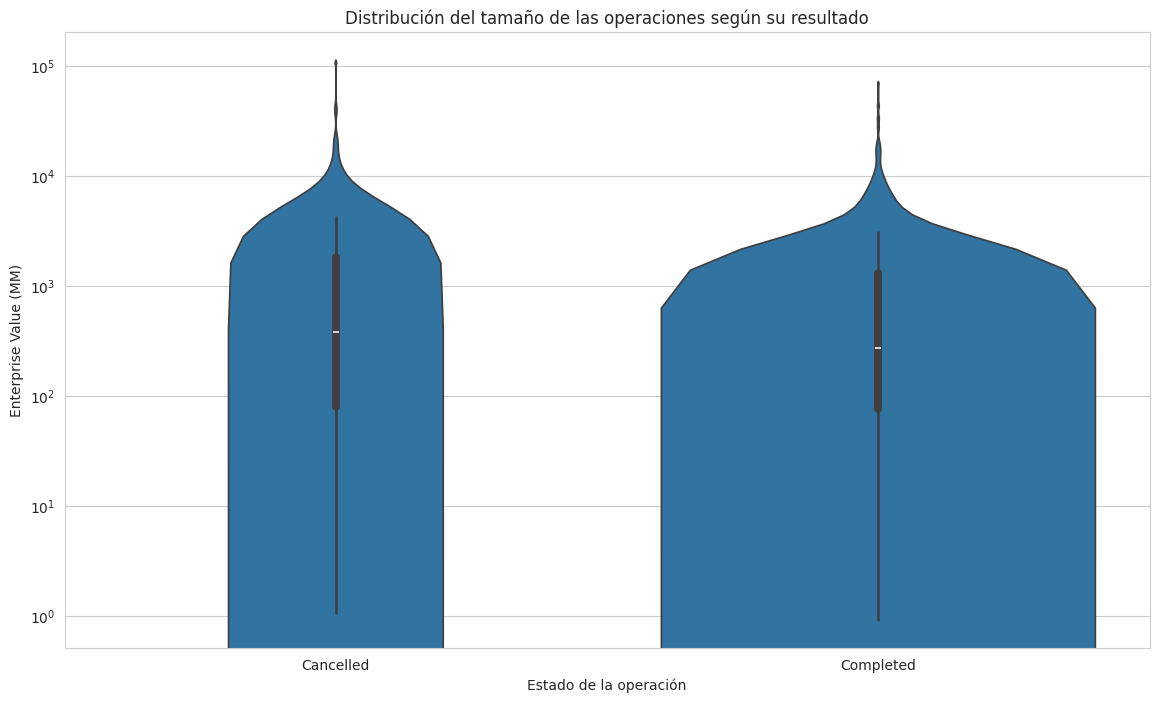

In [ ]:

#5. Gráfico Violín: Distribución del tamaño de las operaciones según su resultado
dff["Status_label"] = dff["Transaction Status"].map({0: "Cancelled", 1: "Completed"})
# Convierte la variable numérica en etiquetas comprensibles:
# 0 → Cancelled, 1 → Completed

# Gráfico
plt.figure(figsize=(14,8))
sns.violinplot(
    x="Status_label",
    y="Enterprise Value (MM)",
    data=dff
)
# Representa la distribución del tamaño de las operaciones según su resultado
# El gráfico de violín muestra:
# - la distribución completa (no solo media)
# - la densidad de los dato

plt.yscale("log")
# Se aplica log porque Enterprise Value tiene mucha dispersión
# evita que los valores grandes distorsionen el gráfico

plt.title("Distribución del tamaño de las operaciones según su resultado")
plt.xlabel("Estado de la operación")
plt.ylabel("Enterprise Value (MM)")
plt.show()

**2.4. VARIABLES SELECCIONADAS**



*   VARIABLE OBJETIVO



Porcentaje de 1 y 0 en la variable 'Transacion Status':


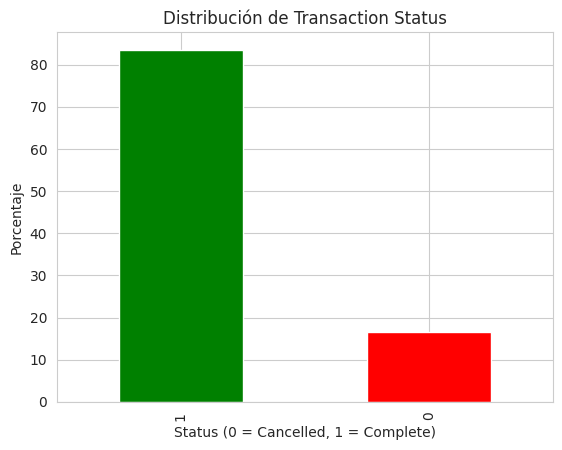

In [ ]:
status_porcent = dff['Transaction Status'].value_counts(normalize=True) * 100
status_porcent
print("Porcentaje de 1 y 0 en la variable 'Transacion Status':")
status_porcent

status_porcent.plot(kind='bar', color=['green', 'red']) #status_porcent contiene las probabilidades de 0 y 1, "bar" indica que queremos un codigo de barras
plt.title('Distribución de Transaction Status')
plt.xlabel('Status (0 = Cancelled, 1 = Complete)') #etiqueta en eje x
plt.ylabel('Porcentaje') #etiqueta en eje y
plt.show()



*   NUEVAS VARIABLES: Leverage, Cash ratio y Log_EV



In [ ]:
#NUEVAS VARIABLES:
dff["Leverage"] = dff["Long Term Debt - Target (MM)"] / (dff["Total Assets - Target (MM)"] + 1)
dff["Cash_ratio"] = dff["Cash - Target (MM)"] / (dff["Total Assets - Target (MM)"] + 1)
dff["Log_EV"] = np.log(dataf["Enterprise Value (MM)"] + 1)

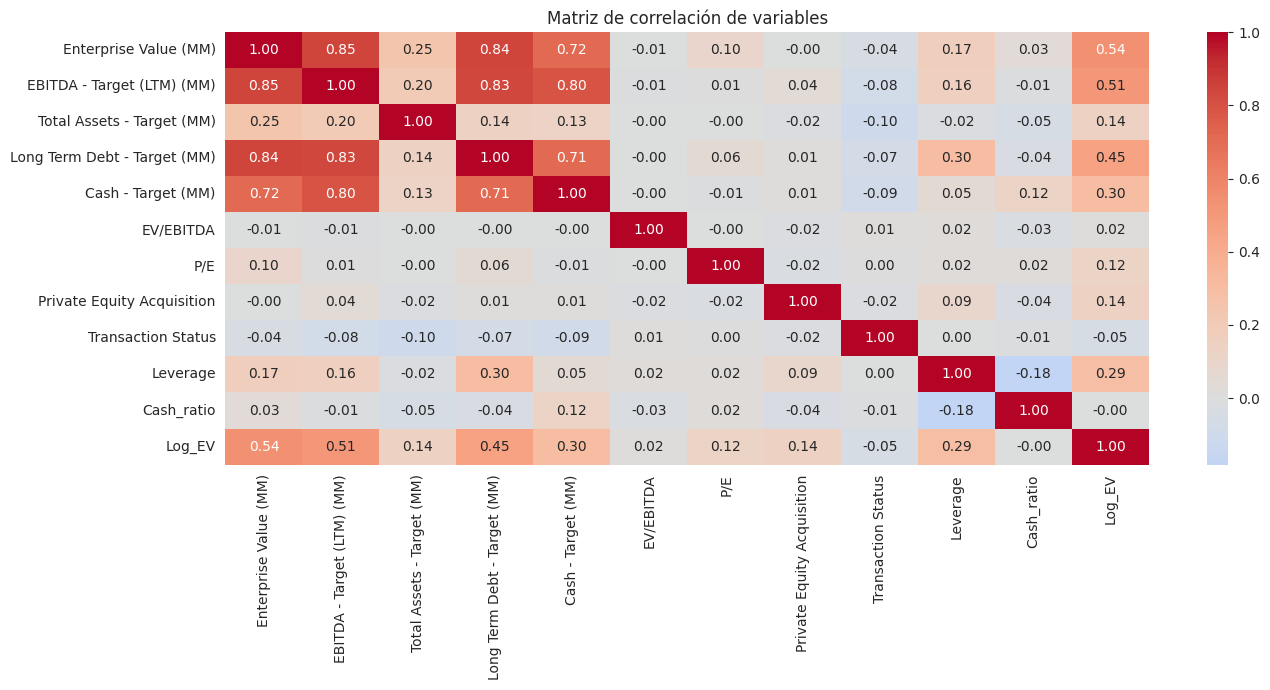

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo variables numéricas
df_numeric = dff.select_dtypes(include=["float64", "int64"])

# Calcular matriz de correlación
corr_matrix = df_numeric.corr()

# Plot
plt.figure(figsize=(14,7))

sns.heatmap(
    corr_matrix,
    annot=True,        # muestra los números
    fmt=".2f",         # formato 2 decimales
    cmap="coolwarm",   # colores rojo-azul
    center=0           # centro en 0
)

plt.title("Matriz de correlación de variables")
plt.tight_layout()
plt.show()

# **3. PREPARACIÓN BASE DE DATOS**

**3.1. ENCODING**

In [ ]:
# 1. Separar
y = dff["Transaction Status"]
X = dff.drop("Transaction Status", axis=1)

print([col for col in X.columns if "status" in col.lower()])

# 2. Encoding SOLO en X
X = pd.get_dummies(X, drop_first=True)

# 3. Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


[]


In [ ]:
#DESBALANCEO DE CLASES: creamos más ejemplos de la clase minortitaria (cancelled)

# Aplicamos SMOTE solo sobre el conjunto de entrenamiento asi evitamos fuga de info
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

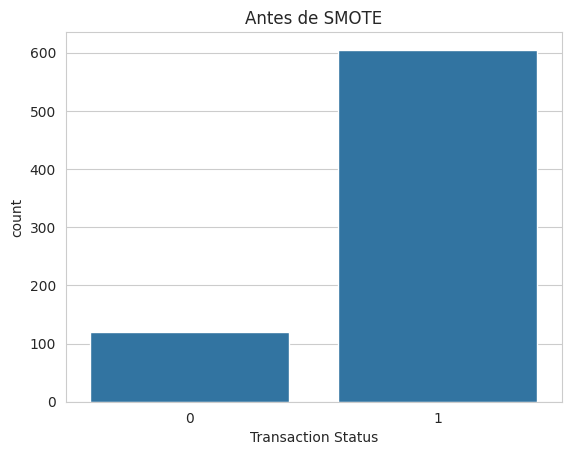

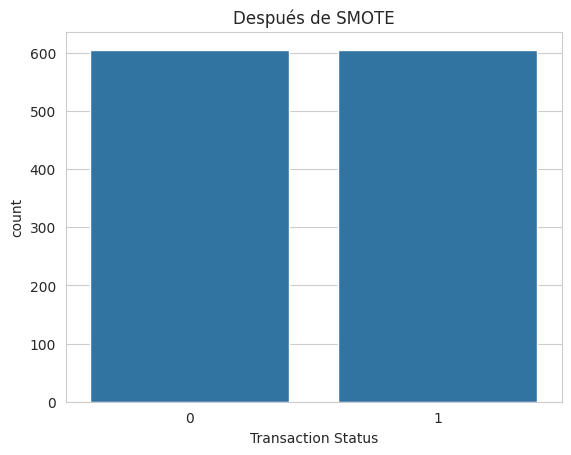

In [ ]:
import seaborn as sns

sns.countplot(x=y_train)
plt.title("Antes de SMOTE")
plt.show()

sns.countplot(x=y_train_res)
plt.title("Después de SMOTE")
plt.show()

In [ ]:
#ESCALADO DE VARIABLES
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# VALIDACIÓN CRUZADA
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring='roc_auc'
)

print("AUC medio:", scores.mean())

AUC medio: 0.540495867768595


3.2. Modelos

In [ ]:
# BASELINE: siempre predice la clase mayoritaria (Completed = 1)

import numpy as np
from sklearn.metrics import accuracy_score

y_pred_baseline = np.ones_like(y_test)  # todo 1

print("Baseline accuracy:", accuracy_score(y_test, y_pred_baseline))

Baseline accuracy: 0.8365384615384616


In [ ]:
# =========================
# MODELO 1: LOGIT
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamos el modelo con datos escalados (importante para Logit)
logit = LogisticRegression(max_iter=1000)
logit.fit(X_train_scaled, y_train_res)

# Predicciones
y_pred_logit = logit.predict(X_test_scaled)
y_prob_logit = logit.predict_proba(X_test_scaled)[:,1]  # Probabilidad clase positiva

# Evaluación
print("=== LOGIT ===")
print(classification_report(y_test, y_pred_logit))

=== LOGIT ===
              precision    recall  f1-score   support

           0       0.20      0.14      0.16        51
           1       0.84      0.89      0.87       261

    accuracy                           0.77       312
   macro avg       0.52      0.51      0.51       312
weighted avg       0.74      0.77      0.75       312



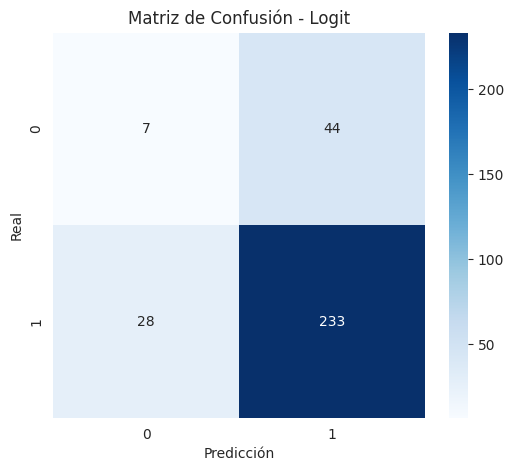

In [ ]:
# Matriz de confusión: compara predicciones vs realidad
cm = confusion_matrix(y_test, y_pred_logit)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Logit")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

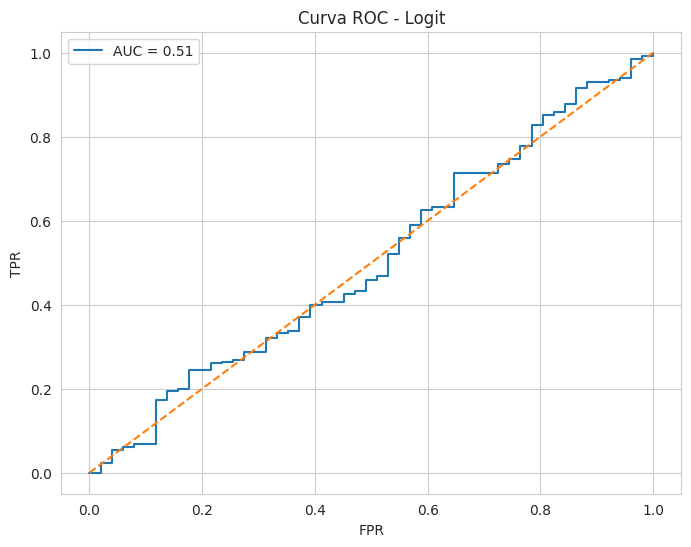

In [ ]:
# Curva ROC: mide capacidad del modelo para distinguir clases
fpr, tpr, _ = roc_curve(y_test, y_prob_logit)
auc_logit = roc_auc_score(y_test, y_prob_logit)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_logit:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("Curva ROC - Logit")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

In [ ]:
# =========================
# MODELO 2: RANDOM FOREST
# =========================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Definimos parámetros a optimizar
param_grid = {
    'n_estimators': [100, 200],     # número de árboles
    'max_depth': [5, 10, None],     # profundidad
    'min_samples_split': [2, 5],    # división nodos
    'class_weight': [None, 'balanced']  # balanceo automático
}

# GridSearch para encontrar mejor modelo
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='roc_auc',  # mejor métrica para desbalanceo
    n_jobs=-1
)

grid_rf.fit(X_train_res, y_train_res)

# Mejor modelo
rf = grid_rf.best_estimator_

print("Mejores parámetros RF:", grid_rf.best_params_)

# Predicciones
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))

Mejores parámetros RF: {'class_weight': None, 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.18      0.14      0.16        51
           1       0.84      0.88      0.86       261

    accuracy                           0.76       312
   macro avg       0.51      0.51      0.51       312
weighted avg       0.73      0.76      0.74       312



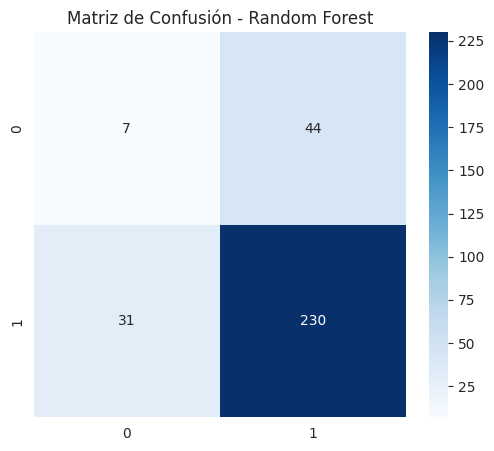

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Random Forest")
plt.show()

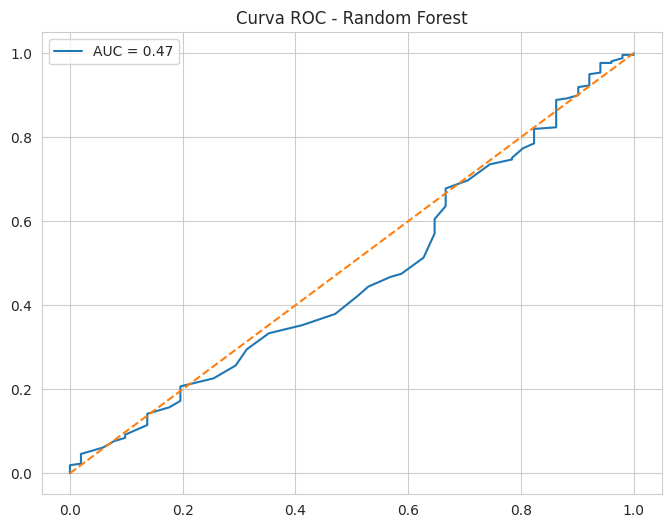

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_rf:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("Curva ROC - Random Forest")
plt.legend()
plt.show()

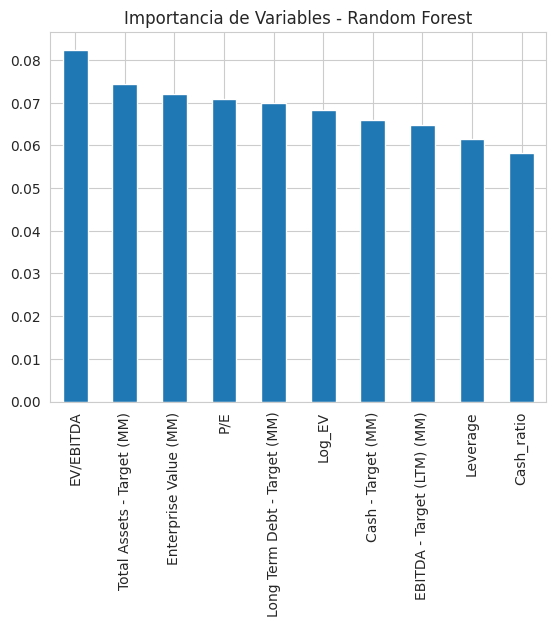

In [ ]:
# Este gráfico es clave para tu TFG (qué variables importan)
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Importancia de Variables - Random Forest")
plt.show()

In [ ]:
# =========================
# MODELO 3: GRADIENT BOOSTING
# =========================

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_res, y_train_res)

# Predicciones
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:,1]

print("=== GRADIENT BOOSTING ===")
print(classification_report(y_test, y_pred_gb))

=== GRADIENT BOOSTING ===
              precision    recall  f1-score   support

           0       0.19      0.20      0.19        51
           1       0.84      0.84      0.84       261

    accuracy                           0.73       312
   macro avg       0.52      0.52      0.52       312
weighted avg       0.74      0.73      0.74       312



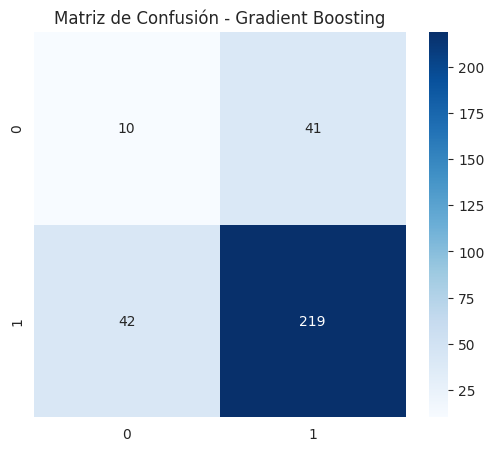

In [ ]:
cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Gradient Boosting")
plt.show()

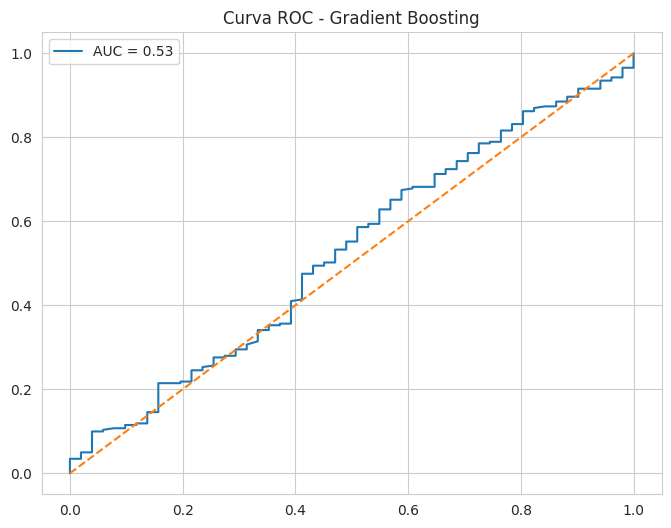

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_gb:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("Curva ROC - Gradient Boosting")
plt.legend()
plt.show()

In [ ]:
# Comparación de modelos en AUC
print("AUC LOGIT:", auc_logit)
print("AUC RF:", auc_rf)
print("AUC GB:", auc_gb)

AUC LOGIT: 0.505371497257907
AUC RF: 0.4700999173615807
AUC GB: 0.5260686650138983


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

def get_metrics(y_true, y_pred, y_prob):

    report = classification_report(y_true, y_pred, output_dict=True)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),

        # Clase 1 (Completed)
        "Precision (Completed)": report["1"]["precision"],
        "Recall (Completed)": report["1"]["recall"],

        # Clase 0 (Cancelled)
        "Precision (Cancelled)": report["0"]["precision"],
        "Recall (Cancelled)": report["0"]["recall"],

        # F1 (puedes usar el de clase 1 o weighted)
        "F1-score (Completed)": report["1"]["f1-score"],

        # AUC
        "AUC-ROC": roc_auc_score(y_true, y_prob)
    }

# ===== BASELINE =====
import numpy as np

y_pred_baseline = np.ones_like(y_test)
y_prob_baseline = np.ones_like(y_test)  # probabilidad 1 para clase positiva

baseline_metrics = get_metrics(y_test, y_pred_baseline, y_prob_baseline)
baseline_metrics["Modelo"] = "Baseline"

# ===== LOGIT =====
logit_metrics = get_metrics(y_test, y_pred_logit, y_prob_logit)
logit_metrics["Modelo"] = "Regresión Logística"

# ===== RANDOM FOREST =====
rf_metrics = get_metrics(y_test, y_pred_rf, y_prob_rf)
rf_metrics["Modelo"] = "Random Forest"

# ===== GRADIENT BOOSTING =====
gb_metrics = get_metrics(y_test, y_pred_gb, y_prob_gb)
gb_metrics["Modelo"] = "Gradient Boosting"

# ===== CREAR TABLA =====
df_results = pd.DataFrame([
    baseline_metrics,
    logit_metrics,
    rf_metrics,
    gb_metrics
])

# Reordenar columnas
df_results = df_results[[
    "Modelo",
    "Accuracy",
    "Precision (Completed)",
    "Recall (Completed)",
    "Precision (Cancelled)",
    "Recall (Cancelled)",
    "F1-score (Completed)",
    "AUC-ROC"
]]

# Redondear
df_results = df_results.round(2)

print(df_results)

                Modelo  Accuracy  Precision (Completed)  Recall (Completed)  \
0             Baseline      0.84                   0.84                1.00   
1  Regresión Logística      0.77                   0.84                0.89   
2        Random Forest      0.76                   0.84                0.88   
3    Gradient Boosting      0.73                   0.84                0.84   

   Precision (Cancelled)  Recall (Cancelled)  F1-score (Completed)  AUC-ROC  
0                   0.00                0.00                  0.91     0.50  
1                   0.20                0.14                  0.87     0.51  
2                   0.18                0.14                  0.86     0.47  
3                   0.19                0.20                  0.84     0.53  


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
df_results.to_excel("tabla_resultados_final.xlsx", index=False)

In [ ]:
print(df_results)

                Modelo  Accuracy  Precision (Completed)  Recall (Completed)  \
0             Baseline      0.84                   0.84                1.00   
1  Regresión Logística      0.77                   0.84                0.89   
2        Random Forest      0.76                   0.84                0.88   
3    Gradient Boosting      0.73                   0.84                0.84   

   Precision (Cancelled)  Recall (Cancelled)  F1-score (Completed)  AUC-ROC  
0                   0.00                0.00                  0.91     0.50  
1                   0.20                0.14                  0.87     0.51  
2                   0.18                0.14                  0.86     0.47  
3                   0.19                0.20                  0.84     0.53  
